<a href="https://colab.research.google.com/github/manavsachdevaa/NLP-learning/blob/main/GradientDescent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
df=pd.read_csv("headbrain.csv")

In [ ]:
df.shape

(237, 4)

In [ ]:
df.head()

,Gender,Age Range,Head Size(cm^3),Brain Weight(grams)
0,1,1,4512,1530
1,1,1,3738,1297
2,1,1,4261,1335
3,1,1,3777,1282
4,1,1,4177,1590


In [ ]:
X=df['Head Size(cm^3)'].values
y=df['Brain Weight(grams)'].values
X,y

(array([4512, 3738, 4261, 3777, 4177, 3585, 3785, 3559, 3613, 3982, 3443,
        3993, 3640, 4208, 3832, 3876, 3497, 3466, 3095, 4424, 3878, 4046,
        3804, 3710, 4747, 4423, 4036, 4022, 3454, 4175, 3787, 3796, 4103,
        4161, 4158, 3814, 3527, 3748, 3334, 3492, 3962, 3505, 4315, 3804,
        3863, 4034, 4308, 3165, 3641, 3644, 3891, 3793, 4270, 4063, 4012,
        3458, 3890, 4166, 3935, 3669, 3866, 3393, 4442, 4253, 3727, 3329,
        3415, 3372, 4430, 4381, 4008, 3858, 4121, 4057, 3824, 3394, 3558,
        3362, 3930, 3835, 3830, 3856, 3249, 3577, 3933, 3850, 3309, 3406,
        3506, 3907, 4160, 3318, 3662, 3899, 3700, 3779, 3473, 3490, 3654,
        3478, 3495, 3834, 3876, 3661, 3618, 3648, 4032, 3399, 3916, 4430,
        3695, 3524, 3571, 3594, 3383, 3499, 3589, 3900, 4114, 3937, 3399,
        4200, 4488, 3614, 4051, 3782, 3391, 3124, 4053, 3582, 3666, 3532,
        4046, 3667, 2857, 3436, 3791, 3302, 3104, 3171, 3572, 3530, 3175,
        3438, 3903, 3899, 3401, 3267, 

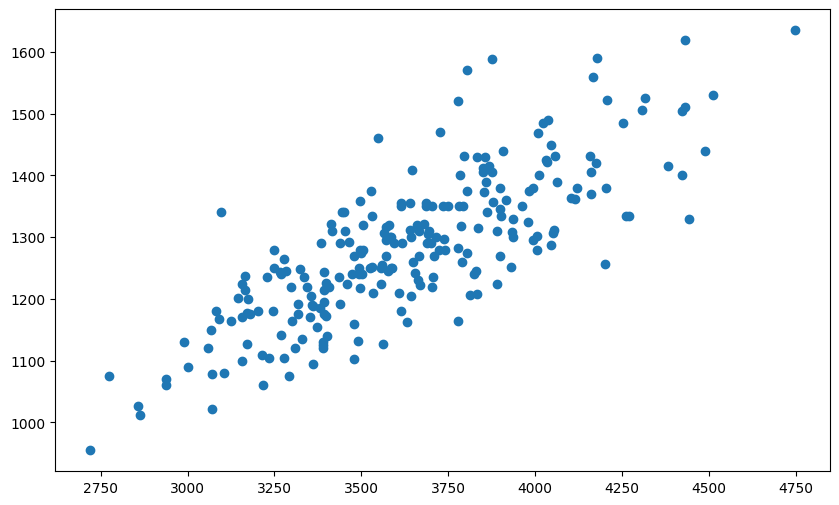

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(X,y)
plt.show()

In [ ]:
mean_x=np.mean(X)
mean_y=np.mean(y)
mean_x,mean_y

(np.float64(3633.9915611814345), np.float64(1282.873417721519))

In [ ]:
numer=0
deno=0
n=len(X)
for i in range(n):
    numer+=(X[i]-mean_x)*(y[i]-mean_y)
    deno+=(X[i]-mean_x)**2
slope=numer/deno
intercept=mean_y-(slope*mean_x)
print("Slope: ",slope)
print("Intercept: ",intercept)

Slope:  0.26342933948939945
Intercept:  325.57342104944223


In [ ]:
prediction=[]
for i in range(n):
  y_pred=(slope*X[i])+intercept
  prediction.append(int(y_pred))

In [ ]:
print("PREDICTION: ",prediction[:5])
print("ACTUAL: ",y[:5])

PREDICTION:  [1514, 1310, 1448, 1320, 1425]
ACTUAL:  [1530 1297 1335 1282 1590]


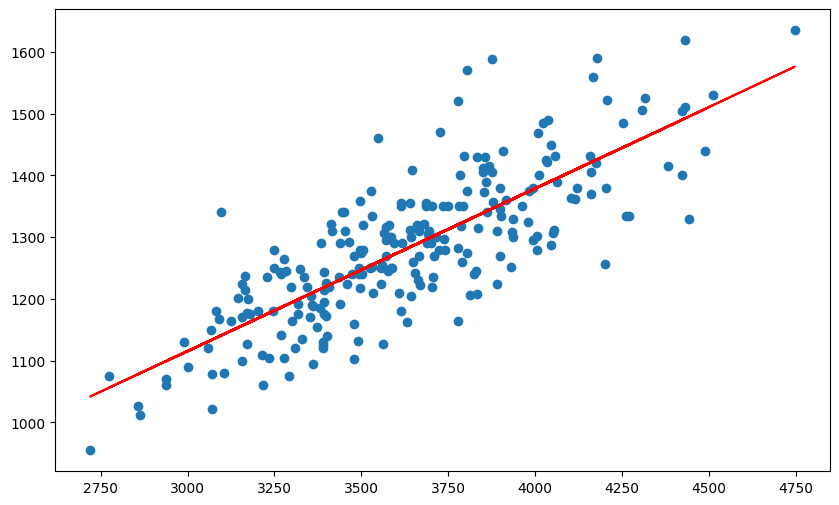

In [ ]:
plt.figure(figsize=(10,6))
plt.scatter(X,y)
plt.plot(X,prediction,'r')
plt.show()

In [ ]:
error=0
for i in range(n):
  error+=(prediction[i]-y[i])**2
mse=error/n
print("MSE: ",mse)
print("RMSE: ",np.sqrt(mse))

MSE:  5202.9029535864975
RMSE:  72.13115106239812


## **GRADIENT DESCENT**

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
X=np.reshape(X,(-1,1))
y=np.reshape(y,(-1,1))
minmax=MinMaxScaler()
scaled_x=minmax.fit_transform(X)
scaled_y=minmax.fit_transform(y)

In [ ]:
scaled_x[:5]

array([[0.88406512],
       [0.50222003],
       [0.7602368 ],
       [0.52146029],
       [0.71879625]])

In [ ]:
def gradient_descent(epochs,alpha):
  slope,inter=0,0
  for i in range(epochs):
    y_pred=scaled_x*slope+inter
    loss=y_pred-scaled_y
    gradSlope=(2/n)*np.sum(loss*scaled_x)
    gradInter=(2/n)*np.sum(loss)
    slope=slope-alpha*gradSlope
    inter=inter-alpha*gradInter
  return slope,inter

In [ ]:
epochs=100
alpha=0.01
slope,inter=gradient_descent(epochs,alpha)
print("Slope: ",slope)
print("Intercept: ",inter)

Slope:  0.20252985740738746
Intercept:  0.3555123649132354


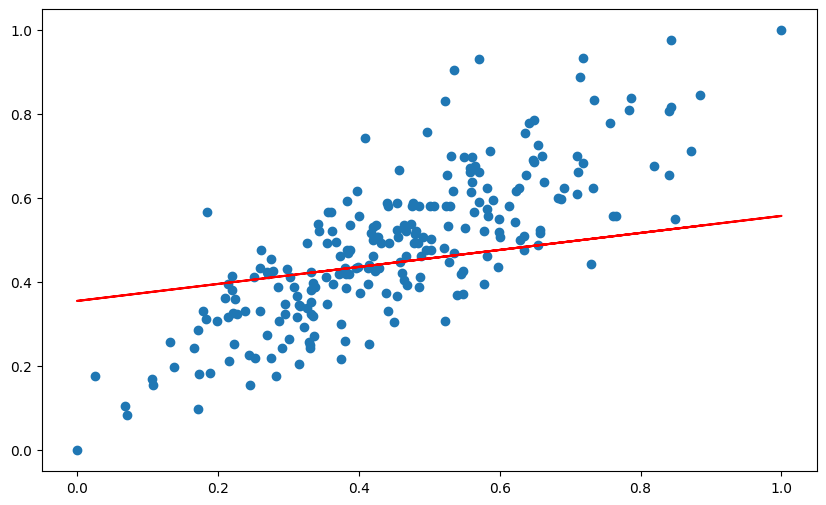

In [ ]:
prediction=[]
for i in range(n):
  y_pred=slope*scaled_x[i] + inter
  prediction.append(y_pred)
plt.figure(figsize=(10,6))
plt.scatter(scaled_x,scaled_y)
plt.plot(scaled_x,prediction,'r')
plt.show()